**KNN IMPLEMENTATION**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("displaynamenow/column-2c-wekacsv")

print("Path to dataset files:", path)

100%|██████████| 11.6k/11.6k [00:00<00:00, 14.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/displaynamenow/column-2c-wekacsv/versions/1


In [ ]:
#distance calculator
#nuclidean distance calculation
def euclidean_distance(p,q):
  return(np.sqrt(np.sum((p-q)**2)))

In [ ]:
#test the distance fx
p1=np.array([3,3,3])
p2=np.array([1,1,2])
dist=euclidean_distance(p1,p2)
print(dist)

In [ ]:
# Define the data
data = [
        [78,3,6],
        [48,2,6],
        [56,3,2],
        [74,3,2],
        [40,3,6],
        [40,3,6],
        [67,2,6],
        [38,5,1.6],
        [49,3.1,1],
        [38.7,2,4],
        [35,3.6,0],
        [50, 0,2]]

# Convert the data to a numpy array
data_np = np.array(data)
# Split the data into X and Y
X = data_np[:, :2] # Select all rows and the first two columns
Y = data_np[:, 2] # Select all rows and the third column
# Display the X and Y arrays to verify
print("X array:")
print(X)
print("\nY array:")
print(Y)

X array:
[[78.   3. ]
 [48.   2. ]
 [56.   3. ]
 [74.   3. ]
 [40.   3. ]
 [40.   3. ]
 [67.   2. ]
 [38.   5. ]
 [49.   3.1]
 [38.7  2. ]
 [35.   3.6]
 [50.   0. ]]

Y array:
[6.  6.  2.  2.  6.  6.  6.  1.6 1.  4.  0.  2. ]


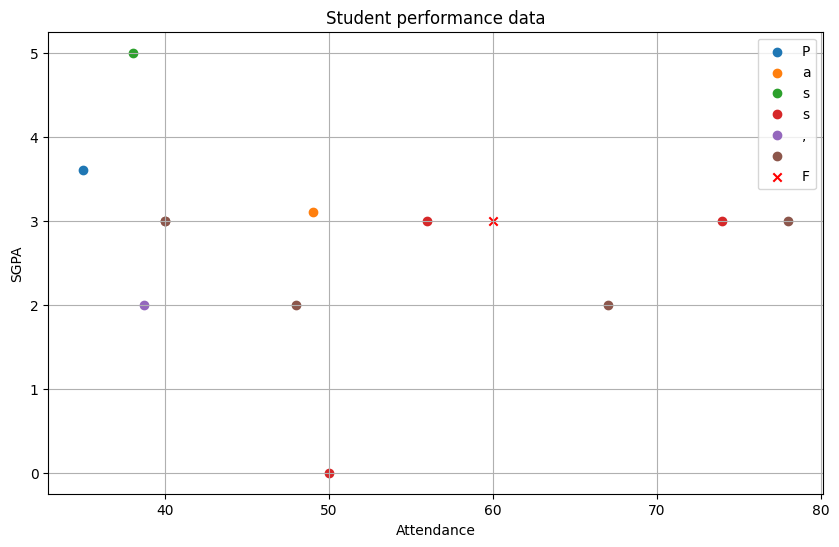

In [ ]:
#data visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
# Separate the data points based on their labels
for label in np.unique(Y):
    plt.scatter(X[Y == label][:, 0], X[Y == label][:, 1], label=f'Class {int(label)}')

#define query_point
query_point=np.array([60,3]) # Corrected to match X's feature dimension
plt.scatter(query_point[0],query_point[1],color='red',marker = 'x', label='query_point')
plt.xlabel('Attendance')
plt.ylabel('SGPA')
plt.title('Student performance data')
plt.legend('Pass, Fail, Query Point')
plt.grid(True)
plt.show()

Task:
X(CRN,CGPA,Attendance) Y(1:pass/0:fail)
list student who pass
and create dataset with 5 to 10 records and display

In [ ]:
#implementation of knn method
from collections import Counter
def knn_classfier(X,y,query_point,k):
  distances=[] # Renamed to avoid conflict with scalar distance

  #calculate the distance between query_point to all other points in the dataset x
  for i, point in enumerate(X):
    current_distance=euclidean_distance(point,query_point)
    distances.append((current_distance,y[i]))

  #sort the distance in ascending order
  distances.sort()
  print(distances)

  #select the top kneighbour
  k_neighbour=current_distance[:k]

  #get label off kk nearest neighbour
  k_nearest_labels=[label for _,label in k]

